# Partial Dependence Plots and ICE Curves

## Overview

**Partial Dependence Plots (PDPs)** show the expected model prediction as a function of one or two features, marginalising over all other features. They answer: "On average, how does the prediction change as feature X varies?"

**Individual Conditional Expectation (ICE) curves** show the same relationship for each observation individually rather than averaging. They reveal heterogeneous effects — when different observations respond differently to the same feature change.

**PDP construction:**
$$\hat{f}_S(x_S) = \frac{1}{n}\sum_{i=1}^n \hat{f}(x_S, x_{C}^{(i)})$$

For each grid value of feature S, set all observations to that value and average the predictions over the observed distribution of all other features (C).

**Critical limitation:** PDPs assume features are independent. When features are correlated, the marginalisation creates unrealistic data combinations (e.g. very high nitrate + very high water quality simultaneously). Use ALE plots for correlated features — see `accumulated_local_effects.ipynb`.

---

## Setup

In [3]:
library(tidyverse)
library(ggplot2)
library(ranger)        # random forest
library(pdp)           # partial(), plotPartial()
library(iml)           # FeatureEffect() — PDPs and ICE via iml
library(patchwork)

set.seed(42)

n <- 500
pdp_data <- tibble(
  nitrate     = runif(n, 1, 10),
  water_qual  = runif(n, 2, 9),
  elevation   = rnorm(n, 200, 80),
  slope_pct   = abs(rnorm(n, 10, 5)),
  richness    = round(
    28 - 2.2*nitrate + 1.5*water_qual +
    0.015*elevation - 0.3*slope_pct +
    rnorm(n, 0, 3)
  )
)

rf_fit <- ranger::ranger(
  richness ~ nitrate + water_qual + elevation + slope_pct,
  data       = pdp_data,
  num.trees  = 500,
  mtry       = 2,
  seed       = 42
)

# iml Predictor object: wraps any model
pred_fn <- function(model, newdata) predict(model, data=newdata)$predictions
predictor <- iml::Predictor$new(
  model     = rf_fit,
  data      = pdp_data %>% select(-richness),
  y         = pdp_data$richness,
  predict.function = pred_fn
)

---

## Partial Dependence Plots

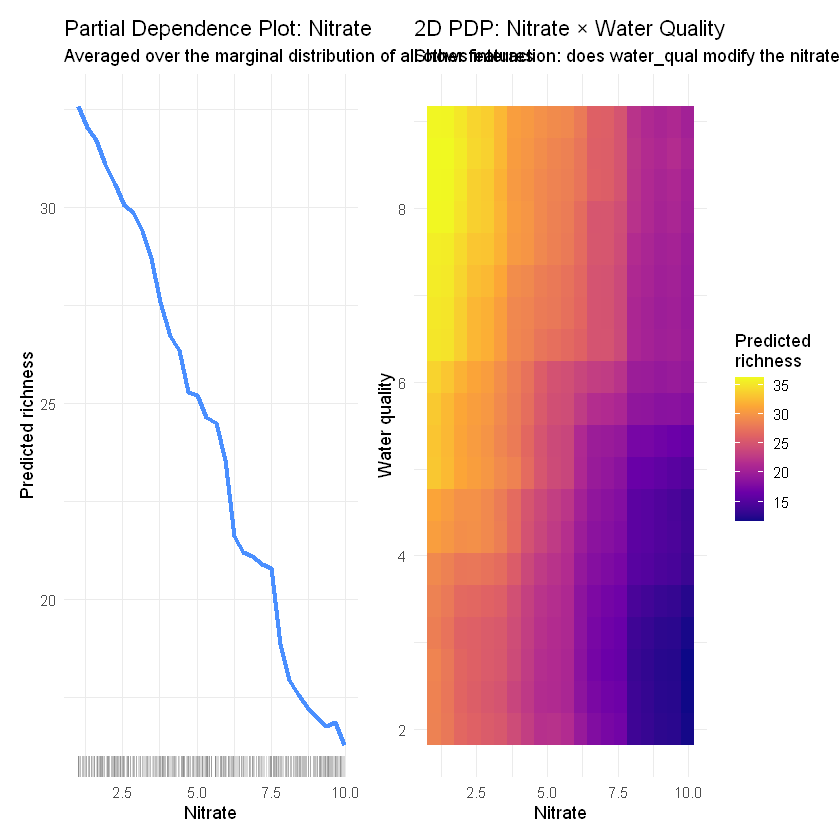

In [4]:
# PDP for nitrate — pdp package (fast; native ranger support)
pdp_nitrate <- pdp::partial(
  rf_fit,
  pred.var = "nitrate",
  train    = pdp_data,
  grid.resolution = 30
)

p_pdp <- ggplot(as_tibble(pdp_nitrate),
                aes(x=nitrate, y=yhat)) +
  geom_line(color="#4a8fff", linewidth=1.2) +
  geom_rug(data=pdp_data, aes(x=nitrate, y=NULL),
           sides="b", alpha=0.3, color="gray50") +
  labs(title="Partial Dependence Plot: Nitrate",
       subtitle="Averaged over the marginal distribution of all other features",
       x="Nitrate", y="Predicted richness") +
  theme_minimal()

# 2D PDP: interaction between two features
pdp_2d <- pdp::partial(
  rf_fit,
  pred.var = c("nitrate","water_qual"),
  train    = pdp_data,
  grid.resolution = 20
)

p_2d <- ggplot(as_tibble(pdp_2d),
               aes(x=nitrate, y=water_qual, fill=yhat)) +
  geom_tile() +
  scale_fill_viridis_c(name="Predicted\nrichness", option="plasma") +
  labs(title="2D PDP: Nitrate × Water Quality",
       subtitle="Shows interaction: does water_qual modify the nitrate effect?",
       x="Nitrate", y="Water quality") +
  theme_minimal()

(p_pdp | p_2d)

---

## ICE Curves: Individual Heterogeneity

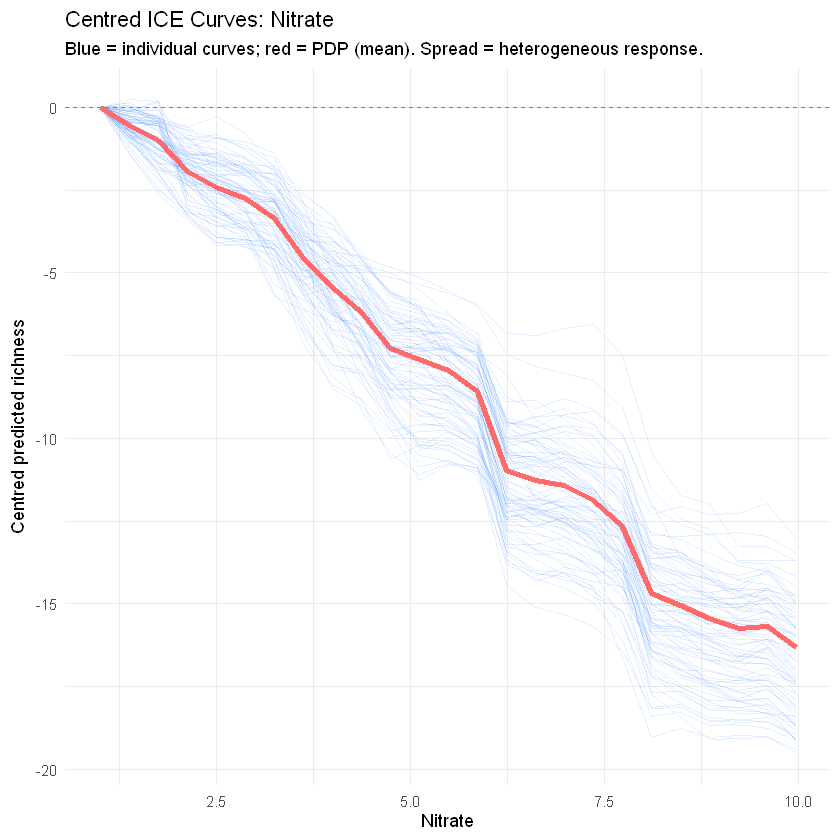

In [5]:
# ICE: one curve per observation; PDP = average of ICE curves
# c-ICE (centred ICE): subtract each curve's value at a reference point
# so curves start at zero — reveals heterogeneity in SLOPE rather than level

ice_nitrate <- pdp::partial(
  rf_fit,
  pred.var = "nitrate",
  train    = pdp_data,
  ice      = TRUE,
  center   = TRUE,   # c-ICE: centred at min(nitrate)
  grid.resolution = 25
)

# Convert to tibble; yhat.id identifies individual curves
ice_df <- as_tibble(ice_nitrate)

# Sample 80 curves to avoid overplotting
sample_ids <- sample(unique(ice_df$yhat.id), 80)

p_ice <- ggplot() +
  geom_line(data = ice_df %>% filter(yhat.id %in% sample_ids),
            aes(x=nitrate, y=yhat, group=yhat.id),
            alpha=0.15, color="#4a8fff", linewidth=0.4) +
  geom_line(
    data = ice_df %>% group_by(nitrate) %>% summarise(yhat=mean(yhat)),
    aes(x=nitrate, y=yhat),
    color="#ff6b6b", linewidth=1.5
  ) +
  geom_hline(yintercept=0, linetype="dashed", color="gray50") +
  labs(title="Centred ICE Curves: Nitrate",
       subtitle="Blue = individual curves; red = PDP (mean). Spread = heterogeneous response.",
       x="Nitrate", y="Centred predicted richness") +
  theme_minimal()

p_ice

# If all ICE curves are parallel: no interaction → PDP is a complete summary
# If curves fan/cross: interaction exists → PDP masks important heterogeneity

---

## Common Pitfalls

**1. Using PDPs when features are correlated**  
PDPs marginalise over the empirical distribution of all other features independently. When features are correlated (e.g. nitrate and phosphorus both high at degraded sites), the marginalisation creates extrapolated, ecologically impossible data combinations. The resulting PDP shape reflects these extrapolations, not the true effect. Use ALE plots — see `accumulated_local_effects.ipynb`.

**2. Interpreting the PDP as the causal effect of a feature**  
A PDP shows how predictions change with a feature — it describes the model, not the data-generating process. If the model has absorbed confounding, the PDP reflects that confounding. PDPs are model-descriptive, not causal.

**3. Not examining ICE curves before reporting PDPs**  
If ICE curves fan out or cross each other, the PDP average is concealing important heterogeneity. A flat PDP combined with wildly divergent ICE curves means the feature has large positive effects for some observations and large negative effects for others — a critical finding that the PDP alone hides.

**4. Plotting PDPs outside the observed feature range**  
PDPs computed at feature values outside the training range involve extrapolation — the model has no training data to ground predictions. Always overlay a rug plot of observed feature values and visually limit interpretation to the range covered by observations.

**5. Comparing PDPs across different models without noting scale differences**  
Two models may have PDPs with the same shape but different y-axis scales if their baseline predictions differ. When comparing the effect of a feature across models, standardise by centring each PDP or use c-ICE curves anchored to a common reference value.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*